In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle
import sklearn

In [38]:
import nltk
from nltk.stem import WordNetLemmatizer
import re
from nltk.corpus import wordnet

In [39]:
#nltk.download("wordnet")
#nltk.download("omw-1.4")
#nltk.download("punkt")

In [40]:
all_data = pd.read_csv("data/Reviews.csv",engine="python")

In [41]:
all_data = all_data[all_data["Score"].isin([1, 3, 5])]

In [ ]:
sentiment_mapping = {
    1: "bad",
    3: "neutral",
    5: "good",
}

In [ ]:
all_data["Score"] = all_data["Score"].map(sentiment_mapping)

In [42]:
all_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...


In [43]:
df = all_data[["Score", "Text"]].copy()

In [44]:
df.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
4,5,Great taffy at a great price. There was a wid...
6,5,This saltwater taffy had great flavors and was...
7,5,This taffy is so good. It is very soft and ch...


In [45]:
df.isna().sum()

Score    0
Text     0
dtype: int64

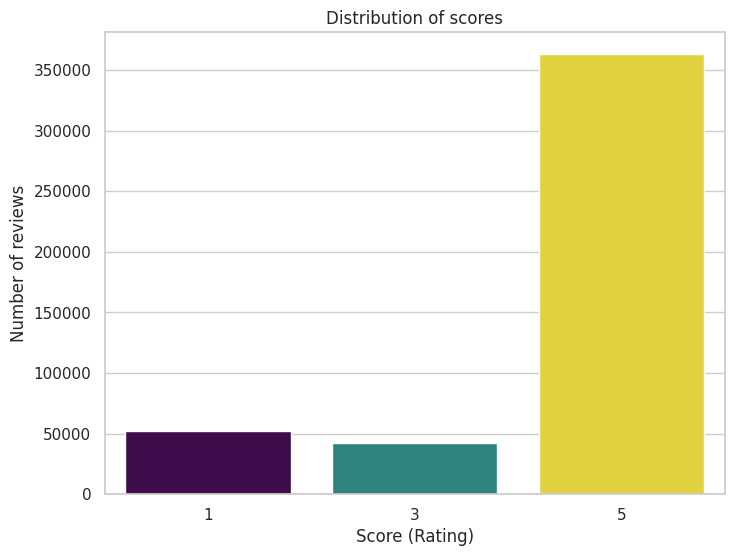

In [46]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.countplot(x="Score", data=df, hue="Score", palette="viridis", legend=False)

plt.title("Distribution of scores")
plt.xlabel("Score (Rating)")
plt.ylabel("Number of reviews")
plt.show()

In [47]:
test_df = df.sample(n=7500, random_state=42)
remaining_df = df.drop(test_df.index)

In [48]:
val_df = remaining_df.sample(n=7500, random_state=42)
train_pool = remaining_df.drop(val_df.index)

In [49]:
samples_per_class = 12000

In [50]:
balanced_dfs = []
for score_val, group in train_pool.groupby("Score"):
  sampled_group = group.sample(n=samples_per_class, random_state=42)
  balanced_dfs.append(sampled_group)

In [51]:
train_balanced = pd.concat(balanced_dfs).reset_index(drop=True)

In [52]:
lemmatizer = WordNetLemmatizer()

In [53]:
def get_wordnet_pos(word):
  tag = nltk.pos_tag([word])[0][1].upper()
  if tag.startswith("J") or tag.startswith("S"):
    return wordnet.ADJ
  elif tag.startswith("V"):
    return wordnet.VERB
  elif tag.startswith("N"):
    return wordnet.NOUN
  elif tag.startswith("R"):
    return wordnet.ADV
  else:
    return wordnet.NOUN  

In [54]:
def lemmatize_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    words = text.split()

    lemmatized_words = [lemmatizer.lemmatize(word, pos=get_wordnet_pos(word)) for word in words]
    return " ".join(lemmatized_words)    

In [55]:
train_balanced["Cleaned_Text"] = train_balanced["Text"].apply(lemmatize_text)
val_df["Cleaned_Text"] = val_df["Text"].apply(lemmatize_text)
test_df["Cleaned_Text"] = test_df["Text"].apply(lemmatize_text)

In [56]:
#test_df

In [57]:
train_balanced.to_csv("data/train_df.csv", index=False)
val_df.to_csv("data/validation_df.csv", index=False)
test_df.to_csv("data/test_df.csv", index=False)

In [58]:
custom_stop_words = list(sklearn.feature_extraction.text.ENGLISH_STOP_WORDS - {"not", "no", "never", "nor","but"})

In [59]:
vectorizer = TfidfVectorizer(max_features=10000,stop_words=custom_stop_words, ngram_range=(1,2), lowercase=True)

In [60]:
X_train_vec = vectorizer.fit_transform(train_balanced["Cleaned_Text"])
y_train = train_balanced["Score"]

In [61]:
X_val_vec = vectorizer.transform(val_df["Cleaned_Text"])
y_val = val_df["Score"]

In [62]:
X_test_vec = vectorizer.transform(test_df["Cleaned_Text"])
y_test = test_df["Score"]

In [63]:
with open("prepared_data.pkl", "wb") as f:
  pickle.dump((X_train_vec, y_train, X_val_vec, y_val, X_test_vec, y_test, vectorizer),f)